In [1]:
version = "v2.2.2"

In [4]:
# update this string!
student_name = "Daniel"

In [5]:
print(f"Notebook version {version}")

if student_name == "First Last":
    raise Exception(
        "Please update your name in the 'student_name' variable at the top of this notebook."
    )

print(f"Student name: {student_name}")

Notebook version v2.2.2
Student name: Daniel


# **Course Minimum Score Notice**
- Student must achieve a _**Passing**_ score on **ALL** course assignments and quizzes to receive credit for this course.  
- What defines a _**Passing**_ score?
  - Students must attain a **Raw Score** of not less than 80.0% on **All** assignments and quizzes.  
  - The **Raw Score** is that score achieved prior to the _final_ application of incurred late penalties. 

<a id='toc'></a>
# Table of Contents
- **[Assignment 2 Description](#Topic0)**
  - [Raw Data with Noise Generation](#rawdata)
  - [Raw Data plot](#rawdataplot)
  - [Task 1a - Polynomial Features](#t1a)
    - [Polynomial Curves Plot #1](#polycurveplots1)
  - [Task 1b - Polynomial Features and Quality of Fit](#t1b)
  - [Task 2a - KNN Regression](#t2a)
  - [Task 2b - Polynomial Model Degree fit](#t2b)
  - [Task 3a - Polynomial fitting with Lasso Regression](#t3a)
    - [Polynomial Curves plot #2](#polycurveplots2)
  - [Task 3b - Lasso regression vs a 'gold standard'](#t3b)
  - [Wisconsin Breast Cancer dataset preparation](#wbcdp)
  - [Task 4 - Applying a SVC to the Wisconsin dataset](#t4)
  - [Gamma vs Accuracy plot](#gap)
  - [Task 5 - Gamma vs Accuracy plot interpretation](#t5)

In [6]:
# Either of the following is no longer
# necessary for matplotlib in notebooks.
# The import statement has you covered!

# %matplotlib notebook
# %matplotlib inline

<a id='Topic0'></a>
# Assignment 2: Regression and Classification

In this assignment we will build several regression and classification models and learn how model complexity relates to generalization performance. 

**Before starting task 1, we recommend you read through *all* the task descriptions in the assignment to get a better idea of the overall narrative for what we're exploring. The output of some tasks is used in subsequent tasks.**

We're going to look at a very common situation in machine learning where:

1. We assume the data are drawn from some true underlying 'gold standard' model that we *can't* observe directly, but that we would like to estimate, since if we know the 'true' model we could in theory do perfect prediction for future examples. In this assignment, the true model will be a polynomial function, but again, we can't observe the exact function.

2. We have our actual dataset, which is drawn from a noisy version of the 'gold standard' function that we *do* observe directly.  This dataset is all we have, and we don't have any information about the added noise. As with any standard machine learning setup, we can divide this dataset into training and test sets: fitting the model using the training points, and evaluating the resulting model on the test points. There's code below that plots the training and test points explicitly.

By using regression on #2, we try to get at #1. We'll see that by making different assumptions about the nature of the underlying true model, we will get different flavors of regression, which in turn will lead to better or worse fits -- according to how well our assumptions match the actual true model. The most basic assumption in task 1 is that the true underlying model *is* a polynomial, but of unknown degree. Later, we assume not only that the true underlying model is a polynomial, but that it has sparse coefficients (Lasso) and you'll evaluate the model fit in that case as well.  

<a href='#toc'>TOC</a>

In [7]:
# Suppress all warnings only when absolutely necessary
# Warnings are in place for a reason!
import warnings

# warnings.filterwarnings('ignore')

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

up, down = True, False

In [ ]:
# np.set_printoptions(precision=3)

## Additional imports can be inlcuded here

In [9]:
# DEGS will be useful throughout!
# Note that an all-CAPS variable in python
# suggests a constant or fixed values.

DEGS = (1, 3, 7, 11)

<a id='rawdata'></a>
### Raw Data with Noise Generation

First, run the following cell to generate and plot the data points we will use throughout the assignment. 

The independent variable $x$ consists of $n$ evenly spaced points from the interval $[0, 20]$ and the dependent variable $y = 0.05x^3 - x^2 - x + C \epsilon$ is a function of $x$ where $\epsilon \sim \mathcal{N}(0, 1)$ represents the standard Gaussian noise and $C$ is a constant indicating the noise magnitude.  

<a href='#toc'>TOC</a>

In [10]:
np.random.seed(0)

C = 15
n = 60
x = np.linspace(0, 20, n)  # x is drawn from a fixed range
y = x**3 / 20 - x**2 - x + C * np.random.randn(n)

# convert x and y from horizontal vector array to a 1-column
# vertical array for use as input to sklearn regression
x = x.reshape(-1, 1)
y = y.reshape(-1, 1)

# Create the training and testing sets and their targets
X_train, X_test, y_train, y_test = train_test_split(x, y, random_state=0)

<a id='rawdataplot'></a>
### Raw Data Plot (optional).

<a href='#toc'>TOC</a>

In [11]:
def data_scatter():
    """
    This function helps you visualize the training and testing sets by drawing a scatter plot of the data points.
    Feel free to change the function in any ways to create your own visuals.
    """
    plt.figure(figsize=(8, 6))
    plt.scatter(X_train, y_train, label="training")
    plt.scatter(X_test, y_test, label="testing")
    plt.legend(loc="best")

    return

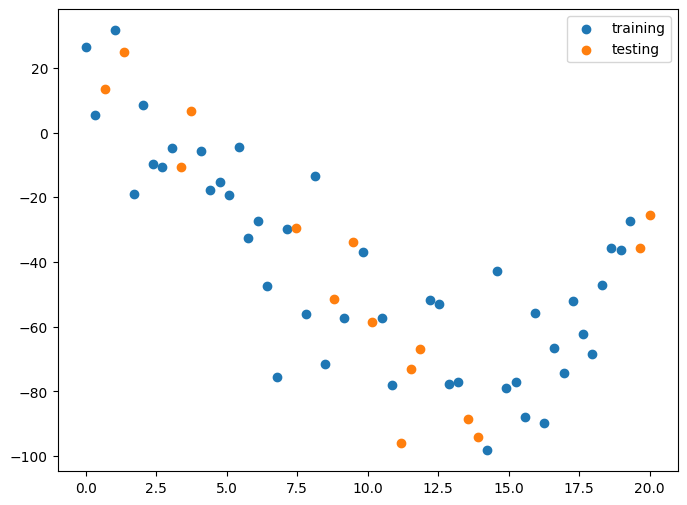

In [12]:
# use this cell to explore the raw dataset
# Remember to comment the following function call before submitting the notebook.

# data_scatter()
data_scatter()

<a id='t1a'></a>
### Task 1a - Polynomial Features (15 points).

From the data generation process we can see that a *linear* function is not sufficient to accurately describe the relationship between $x$ and $y$. What we really need is a *non-linear* regression that relates $x$ and $y$ in a non-linear way, which in our case we conjecture $y$ is a *polynomial* function of various degrees of $x$:

\begin{equation*}
y = a_{0} + a_{1}x + a_{2}x^{2} + \cdots + a_{n}x^{n}
\end{equation*}

where $a_{0}, a_{1}, \cdots, a_{n}$ are the coefficients we want to find. Notice that although $y$ is not a linear function of $x$, it is a linear function of powers of $x$. That means we can still run linear regression, but now on powers of $x$ instead of the zeroth and the first power of $x$ only. To do so we need to create these powers of $x$ out of the $x$ we have now, using the PolynomialFeatures class from [scikit-learn](https://scikit-learn.org/1.2/modules/classes.html). (We recommend you take a look at the polynomial regression examples in the textbook's Section 4.5, Interactions and Polynomials.)

For this task, proceed according to the following steps:

1. Write the code that fits polynomial expansions of the *training data* `X_train`, for degrees 1, 3, 7, 11 respectively, to a [LinearRegression](https://scikit-learn.org/1.2/modules/generated/sklearn.linear_model.LinearRegression.html) model. To do this, first use [PolynomialFeatures](https://scikit-learn.org/1.2/modules/generated/sklearn.preprocessing.PolynomialFeatures.html#sklearn.preprocessing.PolynomialFeatures) to transform the original data so that it adds new additional polynomial features.  


2. For each polynomial regression model you fit in the previous step, use the model to generate predictions for that polynomial's values, using as input 100 evenly spaced points on the interval [0, 20]. To do this, as input to the model, use the expression [np.linspace](https://numpy.org/doc/1.24/reference/generated/numpy.linspace.html)(0, 20, 100).reshape(-1, 1) which gives a 1-column matrix with the desired x-values. Remember that you will first need to call `fit_transform` on this input to add the polynomial feature columns, and then pass that into the predict method on your trained linear regression model. Then convert the 100-row, single-column prediction output to a single row, 100-column array using transpose(). Then stack all the 1-row arrays to create the final prediction output in a single numpy array, whose the first row stores the predictions from the model of degree 1, the second row stores the predictions from the model of degree 3 and so on, and return this numpy array as your result. Among other uses later, the autograder will use these predictions to verify the results of your trained model-fitting.

*This function should return a numpy array of the shape `(4, 100)`.*  

<a href='#toc'>TOC</a>

In [16]:
# hidden autograder codeblock
task_id = "1a"

In [21]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

def polynomial_feature_regression_a():
    preds = None

    # YOUR CODE HERE

    X_eval = np.linspace(0, 20, 100).reshape(-1, 1)
    
    # List to store prediction rows
    results = []
    
    for degree in DEGS:
        # 2. Create polynomial features for the given degree
        poly = PolynomialFeatures(degree=degree)
        X_train_poly = poly.fit_transform(X_train)
        X_eval_poly = poly.transform(X_eval)
        
        # 3. Fit the Linear Regression model
        linreg = LinearRegression().fit(X_train_poly, y_train)
        
        # 4. Predict on the evaluation points
        # Flatten the prediction to a 1D array of 100 elements
        y_pred = linreg.predict(X_eval_poly).flatten()
        results.append(y_pred)
        
    # 5. Stack the results into a (4, 100) numpy array
    preds = np.array(results)

    #raise NotImplementedError()

    return preds

In [24]:
# use this cell to explore your solution
# Remember to comment the following function call before submitting the notebook.

# polynomial_feature_regression_a()

In [23]:
# Autograder tests
print(f"Task {task_id} - AG tests")

stu_ans = polynomial_feature_regression_a()

# print(f"Task {task_id} - your answer:\n{stu_ans}")

assert isinstance(
    stu_ans, np.ndarray
), f"Task {task_id}: Your function should return a np.ndarray. "
assert stu_ans.shape == (
    4,
    100,
), f"Task {task_id}: Your np.ndarray is of an incorrect shape. "

# Some hidden tests

del stu_ans

Task 1a - AG tests


<a id='polycurveplots1'></a>
### Polynomial Curves plot \#1 (optional).
Now let's visualize the polynomials we learned from the training data, along with the training and the testing data.  
Feel free to change this function in any way to create your own visuals.  

<a href='#toc'>TOC</a>

In [25]:
def plot_one(predictions):
    x_values = np.linspace(0, 20, 100)

    plt.figure(figsize=(10, 8))

    plt.plot(X_train, y_train, "o", label="training", markersize=9)
    plt.plot(X_test, y_test, "o", label="testing", markersize=9)

    for i, deg in enumerate(DEGS):
        plt.plot(
            x_values,
            predictions[i],
            alpha=0.8,
            lw=2,
            label=f"degree = {deg}",
        )

    plt.legend(loc="best")

    return

In [27]:
# use this cell to explore your solution
# Remember to comment the following function call before submitting the notebook.

#plot_one(polynomial_feature_regression_a())

<a id='t1b'></a>
### Task 1b - Polynomial Features and Quality of Fit (15 points).

Write a function that fits a polynomial LinearRegression model on the training data `X_train` for degrees = (1, 3, 7, 11). For each model compute the $R^2$ (coefficient of determination) regression score on the training data as well as the the testing data. 

*This function should return a tuple of lists `(r2_train, r2_test)`, where `r2_train` contains the $R^{2}$ scores on the training data and the other contains the $R^{2}$ scores on the testing data.*  
You may choose to use the sklearn **[r2_score](https://scikit-learn.org/1.2/modules/generated/sklearn.metrics.r2_score.html#sklearn.metrics.r2_score)** function.  

<a href='#toc'>TOC</a>

In [38]:
# hidden autograder codeblock
task_id = "1b"

In [42]:
from sklearn.metrics import r2_score

def polynomial_feature_regression_b():
    r2_train, r2_test = [], []

    # YOUR CODE HERE

    for degree in DEGS:
        # 1. Initialize the PolynomialFeatures transformer
        poly = PolynomialFeatures(degree=degree)
        
        # 2. Transform the training and testing data
        # Note: We fit on the training data, but only transform the test data
        X_train_poly = poly.fit_transform(X_train)
        X_test_poly = poly.transform(X_test)
        
        # 3. Fit the Linear Regression model on the training data
        linreg = LinearRegression().fit(X_train_poly, y_train)
        
        # 4. Generate predictions for both sets
        y_train_pred = linreg.predict(X_train_poly)
        y_test_pred = linreg.predict(X_test_poly)
        
        # 5. Calculate the R^2 scores
        score_train = r2_score(y_train, y_train_pred)
        score_test = r2_score(y_test, y_test_pred)
        
        # 6. Append the scores to our respective lists
        r2_train.append(score_train)
        r2_test.append(score_test)
    
    #raise NotImplementedError()

    return r2_train, r2_test

In [43]:
# use this cell to explore your solution
# Remember to comment the following function call before submitting the notebook.

# polynomial_feature_regression_b()

In [44]:
# Autograder tests
print(f"Task {task_id} - AG tests")
stu_ans = polynomial_feature_regression_b()

print(f"Task {task_id} - your answer:\n{stu_ans}")

assert isinstance(
    stu_ans, tuple
), f"Task {task_id}: Your function should return a tuple. "
assert len(stu_ans) == 2, f"Task {task_id}: The tuple returned should be of length 2. "
assert isinstance(stu_ans[0], list) and isinstance(
    stu_ans[1], list
), f"Task {task_id}: The tuple should contain only lists. "

# Some hidden tests

del stu_ans

Task 1b - AG tests
Task 1b - your answer:
([0.5146908335931619, 0.7716782246401617, 0.7905134245393499, 0.7956778065234407], [0.3660750337906714, 0.8666116934853964, 0.8114944986107406, 0.6552378442014382])


<a id='t2a'></a>
### Task 2a - KNN Regression (10 points).

Fit a KNN regression model with the training data and return the $R^{2}$ value on the testing data. Use the default hyper-parameters. 

*This function should return a single `float` value.*

<a href='#toc'>TOC</a>

In [ ]:
# hidden autograder codeblock
task_id = "2a"

In [45]:
from sklearn.neighbors import KNeighborsRegressor
def knn_regresssion():
    r2 = None

    # YOUR CODE HERE

    # 1. Initialize the KNN Regressor (defaults will be used automatically)
    knn = KNeighborsRegressor()
    
    # 2. Fit the model using the training data
    knn.fit(X_train, y_train)
    
    # 3. Calculate the R^2 score on the testing data
    # Note: Scikit-learn regressors have a built-in .score() method 
    # that automatically computes the R^2 value for us!
    r2 = knn.score(X_test, y_test)
    
    # (Alternatively, you could do: r2 = r2_score(y_test, knn.predict(X_test)))

    #raise NotImplementedError()

    return r2

In [46]:
# use this cell to explore your solution
# Remember to comment the following function call before submitting the notebook.

# knn_regresssion()

In [47]:
# Autograder tests
print(f"Task {task_id} - AG tests")
stu_ans = knn_regresssion()

print(f"Task {task_id} - your answer:\n{stu_ans}")

assert isinstance(
    stu_ans, float
), f"Task {task_id}: Your function should return a single float number. "

# Some hidden tests

del stu_ans

Task 1b - AG tests
Task 1b - your answer:
0.7770358819030301


<a id='t2b'></a>
### Task 2b - Polynomial Model Degree fit: under, over, optimal (5 points).

Based on the $R^2$ scores from Task 1b, which degree of the polynomial causes the model to be
 - underfitting; 
 - overfitting; or
 - achieving good generalisation performance? 

Hint: Try to plot the degrees of the polynomial against the $R^2$ scores to visualise their relationship. 

Your function should return a 3-tuple with the degree values in this order: (Underfitting, Overfitting, Good_Generalization)
Some answers may have more than one value that will be accepted as correct.  

<a href='#toc'>TOC</a>

In [ ]:
# hidden autograder codeblock
task_id = "2b"

In [48]:
def task_2b():
    result = None
    # YOUR CODE HERE

    # The format is (Underfitting, Overfitting, Good_Generalization)
    result = (1, 11, 3)
    
    #raise NotImplementedError()

    return result

In [49]:
# use this cell to explore your solution
# Remember to comment the following function call before submitting the notebook.

# task_2b()

In [50]:
# Autograder tests
print(f"Task {task_id} - AG tests")
stu_ans = task_2b()

print(f"Task {task_id} - your answer:\n{stu_ans}")

assert isinstance(stu_ans, tuple), f"Task {task_id}: You should return a tuple."
assert len(stu_ans) == 3, f"Task {task_id}: Your tuple must have 3 elements."

# Some hidden tests
del stu_ans

Task 1b - AG tests
Task 1b - your answer:
(1, 11, 3)


<a id='t3a'></a>
### Task 3a - Polynomial fitting with Lasso Regression (15 points).

Training models on high-degree polynomial features can result in overly complex models that overfit the training data, so we often add some regularization to constrain the model complexity as we saw in Ridge and Lasso regression.

For this task, you will be comparing the non-regularized `LinearRegression` model (with the default hyper-parameters) that you built for task 1, to a new regularised Lasso Regression model (with hyper-parameters `alpha=0.01`, `max_iter=10000`) --- on polynomial features of varying degrees, so you can see the difference with the polynomials that were fit in task 1.

Your function should return predictions for the regularized model using the same method and in the same format that you used for task 1: namely, you generate predictions for 100 evenly spaced points on the interval [0, 20] and store the results in a numpy array, whose the first row stores the predictions from the model of degree 1, the second row stores the predictions from the model of degree 3 and so on.

*This function should return a numpy array of the shape `(4, 100)`.*

Once you have successful generated these predictions, plot them using the provided function and compare with the polynomial fit in task 1. What do you observe?  What explains what you observe?  (These questions are for your insight only - they are not graded.)  

<a href='#toc'>TOC</a>

In [ ]:
# hidden autograder codeblock
task_id = "3a"

In [55]:
# enable below if ConvergenceWarnings from Lasso
warnings.simplefilter("ignore")
from sklearn.linear_model import Lasso

def polynomial_lasso_regression_a():
    preds = []

    # YOUR CODE HERE

    # 1. Create the 100 evaluation points on the interval [0, 20]
    X_eval = np.linspace(0, 20, 100).reshape(-1, 1)
    
    for degree in DEGS:
        # 2. Create polynomial features for the given degree
        poly = PolynomialFeatures(degree=degree)
        X_train_poly = poly.fit_transform(X_train)
        X_eval_poly = poly.transform(X_eval)
        
        # 3. Initialize and fit the Lasso model with the requested hyperparameters
        lasso = Lasso(alpha=0.01, max_iter=10000)
        lasso.fit(X_train_poly, y_train)
        
        # 4. Predict on the evaluation points and flatten to a 1D array
        y_pred = lasso.predict(X_eval_poly).flatten()
        
        # 5. Append the predictions to our list
        preds.append(y_pred)
        
    # 6. Convert the list of predictions into a numpy array
    preds = np.array(preds)
    
    #raise NotImplementedError()

    return preds

In [56]:
# use this cell to explore your solution
# Remember to comment the following function call before submitting the notebook.

# polynomial_lasso_regression_a()

In [57]:
# Autograder tests
print(f"Task {task_id} - AG tests")
stu_ans = polynomial_lasso_regression_a()

# print(f"Task {task_id} - your answer:\n{stu_ans}")

assert isinstance(
    stu_ans, np.ndarray
), f"Task {task_id}: Your function should return a np.ndarray. "
assert stu_ans.shape == (
    4,
    100,
), f"Task {task_id}: Your np.ndarray is of an incorrect shape: it should be (4, 100)."

# Some hidden tests

del stu_ans

Task 1b - AG tests


<a id='polycurveplots2'></a>
### Polynomial Curves plot \#2 (optional).
Now let's visualize the polynomials we learned from the training data, along with the training and the testing data.  

<a href='#toc'>TOC</a>

In [58]:
# use this cell to explore your solution
# Remember to comment the following function call before submitting the notebook.

# plot_one(polynomial_lasso_regression_a())

<a id='t3b'></a>
### Task 3b - Lasso regression vs a 'gold standard' dataset (20 points) 

Return the $R^2$ score for each of the Lasso models above relative to a new 'gold standard' test set generated from the true underlying cubic polynomial model without noise.  Compute this test set by computing the true noise-less underlying function `t^3/20 - t^2 - t` for each of 100 evenly spaced points on the interval [0, 20] (the same as you've used in previous tasks).  For each degree (1, 3, 7, 11), compute the $R^2$ score using this 'gold standard' test set and return the polynomial degree that gives the best fit on the 'gold standard' test set. Your function should return an integer, which should be in the set (1,3,7,11).  Does the optimal polynomial degree match the true polynomial degree?  

<a href='#toc'>TOC</a>

In [59]:
# hidden autograder codeblock
task_id = "3b"

In [60]:
def polynomial_lasso_regression_b():
    best_deg = []
  
    # YOUR CODE HERE

    # 1. Create the 100 evaluation points
    X_eval = np.linspace(0, 20, 100).reshape(-1, 1)
    
    # 2. Compute the 'gold standard' noise-less target values
    y_true = (X_eval**3) / 20 - (X_eval**2) - X_eval
    
    # Variable to keep track of the highest R^2 score we see
    best_r2 = -float('inf') 
    
    # 3. Iterate through the degrees
    for degree in DEGS:
        # Create polynomial features
        poly = PolynomialFeatures(degree=degree)
        X_train_poly = poly.fit_transform(X_train)
        X_eval_poly = poly.transform(X_eval)
        
        # Fit the Lasso model on the training data
        lasso = Lasso(alpha=0.01, max_iter=10000)
        lasso.fit(X_train_poly, y_train)
        
        # Predict on the evaluation points
        y_pred = lasso.predict(X_eval_poly)
        
        # Calculate the R^2 score against the perfect gold standard
        current_r2 = r2_score(y_true, y_pred)
        
        # 4. Check if this is our new best score
        if current_r2 > best_r2:
            best_r2 = current_r2
            best_deg = degree
    
    #raise NotImplementedError()

    return best_deg

In [61]:
# use this cell to explore your solution
# Remember to comment the following function call before submitting the notebook.

# polynomial_lasso_regression_b()

In [62]:
# Autograder tests
print(f"Task {task_id} - AG tests")
stu_ans = polynomial_lasso_regression_b()

print(f"Task {task_id} - your answer:\n{stu_ans}")

assert isinstance(
    stu_ans, int
), f"Task {task_id}: Your function should return an integer. "

# Some hidden tests

del stu_ans

Task 3b - AG tests
Task 3b - your answer:
3


<a id='wbcdp'></a>
### [Breast Cancer Wisconsin](https://scikit-learn.org/1.2/modules/generated/sklearn.datasets.load_breast_cancer.html#sklearn.datasets.load_breast_cancer) dataset preparation.

<a href='#toc'>TOC</a>

In [63]:
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()

data = np.hstack([cancer["data"], cancer["target"].reshape(-1, 1)])
col_names = np.hstack([cancer["feature_names"], ["target"]])
cancer_df = pd.DataFrame(data, columns=col_names)

X_cancer, y_cancer = cancer_df.iloc[:, :-1], cancer_df.iloc[:, -1]

In [ ]:
# use this cell to explore your solution
# Remember to comment the following function call before submitting the notebook.

# cancer_df.head()

<a id='t4'></a>
### Task 4 - Applying a SVC to the Wisconsin dataset (15 points).

We're going to return to the [Breast Cancer Wisconsin](https://scikit-learn.org/1.2/modules/generated/sklearn.datasets.load_breast_cancer.html#sklearn.datasets.load_breast_cancer) dataset to apply our newly learned Support Vector classifier, [SVC](https://scikit-learn.org/1.2/modules/generated/sklearn.svm.SVC.html#sklearn.svm.SVC).

For this task, we're also going to use the [validation_curve](https://scikit-learn.org/1.2/modules/generated/sklearn.model_selection.validation_curve.html#sklearn.model_selection.validation_curve) function in [sklearn.model_selection](https://scikit-learn.org/1.2/modules/classes.html#module-sklearn.model_selection) to determine training and test scores for the Support Vector Classifier with varying parameter values.

Create an `SVC` with default parameters (i.e. `kernel='rbf', C=1`) and `random_state=0`. Recall that the kernel width of the RBF kernel is controlled using the `gamma` parameter.  Explore the effect of `gamma` on classifier accuracy by using the `validation_curve` function to find the training and test scores for 6 values of `gamma` from `1e-7` to `1e-2` (i.e. `np.logspace(-7, -2, 6, endpoint=True)`, or more precisely `[1.e-07, 1.e-06, 1.e-05, 1.e-04, 1.e-03, 1.e-02]`).

For each level of `gamma`, set parameter `cv=3` so that `validation_curve` will fit 3 models on different subsets of the data, returning two 6x3 (6 levels of gamma x 3 fits per level) arrays of the scores for the training and test sets. 

Find the mean score across the three models for each level of `gamma` for both arrays, creating two arrays of length 6, and return a tuple with the two arrays.

e.g.

if one of your array of scores is

    array([[ 0.5,  0.4,  0.6],
           [ 0.7,  0.8,  0.7],
           [ 0.9,  0.8,  0.8],
           [ 0.8,  0.7,  0.8],
           [ 0.7,  0.6,  0.6],
           [ 0.4,  0.6,  0.5]])
       
it should then become

    array([ 0.5,  0.73333333,  0.83333333,  0.76666667,  0.63333333, 0.5])

*This function should return a tuple of numpy arrays `(training_scores, test_scores)` where each array in the tuple has shape `(6,)`.*  

<a href='#toc'>TOC</a>

In [64]:
# hidden autograder codeblock
task_id = "4"

In [66]:
from sklearn.svm import SVC
from sklearn.model_selection import validation_curve

def svc_classifier():
    results = None

    # YOUR CODE HERE

    # 1. Initialize the SVC model with the requested parameters
    svc = SVC(kernel='rbf', C=1, random_state=0)
    
    # 2. Define the gamma values to test (10^-7 to 10^-2)
    gamma_range = np.logspace(-7, -2, 6, endpoint=True)
    
    # 3. Use validation_curve to get the training and testing scores
    # Make sure to use the newly prepared dataset: X_cancer, y_cancer
    train_scores, test_scores = validation_curve(
        estimator=svc, 
        X=X_cancer, 
        y=y_cancer, 
        param_name='gamma', 
        param_range=gamma_range, 
        cv=3
    )
    
    # 4. Calculate the mean score across the 3 cross-validation folds (axis=1)
    # This turns our (6, 3) arrays into (6,) arrays
    train_mean = np.mean(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    
    # 5. Store the result as a tuple
    results = (train_mean, test_mean)
    
    #raise NotImplementedError()

    return results

In [67]:
# use this cell to explore your solution
# Remember to comment the following function call before submitting the notebook.

# svc_classifier()

In [68]:
# Autograder tests
print(f"Task {task_id} - AG tests")
stu_ans = svc_classifier()

print(f"Task {task_id} - your answer:\n{stu_ans}")

assert isinstance(
    stu_ans, tuple
), f"Task {task_id}: You should return a tuple (of two arrays)"

assert stu_ans[0].shape == (
    6,
), f"Task {task_id}: Please check the shape of your first returned array: it should be (6,)."

assert stu_ans[1].shape == (
    6,
), f"Task {task_id}: Please check the shape of your second returned array: it should be (6,)."

# Some hidden tests

del stu_ans

Task 4 - AG tests
Task 4 - your answer:
(array([0.89631301, 0.91653011, 0.92882007, 0.95166644, 0.9780262 ,
       1.        ]), array([0.89462545, 0.91218788, 0.91918686, 0.93146756, 0.92089483,
       0.62565673]))


<a id='gap'></a>
### Gamma vs Accuracy plot

Based on the scores from the previous task, what gamma value corresponds to a model that is underfitting? What gamma value corresponds to a model that is overfitting? What choice of gamma would provide a model with good generalization performance on this dataset?

(Hint: Try plotting the scores from the previous task to visualize the relationship. Code is provided below.)

This function should return a tuple with the gamma values in this order: (Underfitting, Overfitting, Good_Generalization)
You must enter these values in the format 1e-N, where N is the exponent, and the gamma value must be one of the values in the list `[1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2]`.  Some answers have more than one value that will be accepted as correct.  

<a href='#toc'>TOC</a>

In [69]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def plot_train_test_acc():
    a, b = svc_classifier()
    x = np.arange(-7, -1, 1)

    plt.figure(figsize=(8, 6))
    plt.plot(x, a, label="Avg Train Acc")
    plt.plot(x, b, label="Avg Test Acc")
    plt.xticks(x)
    plt.xlabel("log scale: gamma parameter")
    plt.ylabel("Accuracy")
    plt.grid(alpha=0.2)
    plt.legend()

    return

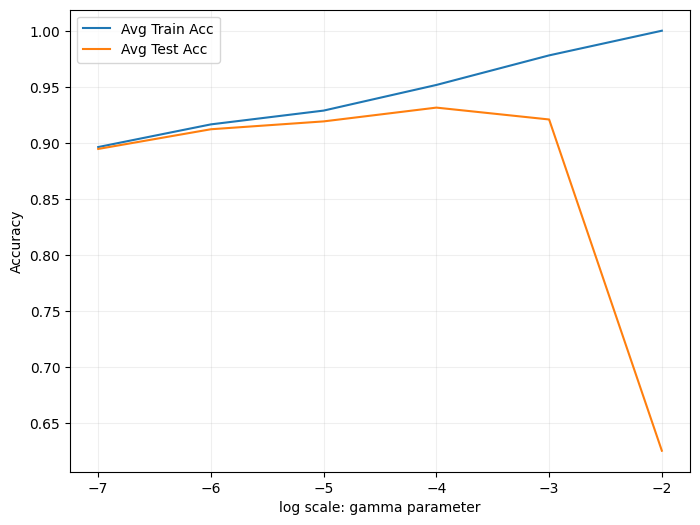

In [70]:
# use this cell to explore your solution
# Remember to comment the following function call before submitting the notebook.

plot_train_test_acc()

<a id='t5'></a>
### Task 5 -  Gamma vs Accuracy plot interpretation (5 points).

<a href='#toc'>TOC</a>

In [74]:
# hidden autograder codeblock
task_id = "5"

In [75]:
def task_five():
    result = None

    # YOUR CODE HERE

    result = (1e-7, 1e-2, 1e-4)
    
    #raise NotImplementedError()

    return result

In [76]:
# use this cell to explore your solution
# Remember to comment the following function call before submitting the notebook.

#task_five()

In [77]:
# Autograder tests
print(f"Task {task_id} - AG tests")
stu_ans = task_five()

print(f"Task {task_id} - your answer:\n{stu_ans}")

assert isinstance(stu_ans, tuple), f"Task {task_id}: You should return a tuple."
assert len(stu_ans) == 3, f"Task {task_id}: Your tuple must have 3 elements."

del stu_ans

Task 5 - AG tests
Task 5 - your answer:
(1e-07, 0.01, 0.0001)


<a href='#toc'>TOC</a>